<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/dev/Brain_Tumor_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Set Up Your Colab Environment

First, you'll need to upload your `kaggle.json` file, which contains your Kaggle API credentials.

### Step 2: Get Your Kaggle Dataset into Colab

Next, we'll set up the Kaggle API key and download the brain tumor MRI dataset. Remember to replace the dataset path with the correct one if you're using a different dataset.

In [ ]:
# Make a directory for the Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download your dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
  0% 0.00/149M [00:00<?, ?B/s]
100% 149M/149M [00:00<00:00, 1.56GB/s]


In [ ]:
# Unzip the downloaded file
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

### Step 3: Begin Data Exploration and Analysis

Now that the data is downloaded and unzipped, we can start exploring it. This code will load the image paths and labels into a pandas DataFrame, check the class distribution, and display some sample images.

Total number of images: 7023

Number of images per class:
label
notumor       2000
pituitary     1757
meningioma    1645
glioma        1621
Name: count, dtype: int64

First 5 rows of the DataFrame:


,file_path,label
0,Training/pituitary/Tr-pi_1430.jpg,pituitary
1,Training/pituitary/Tr-pi_0149.jpg,pituitary
2,Training/pituitary/Tr-pi_0351.jpg,pituitary
3,Training/pituitary/Tr-pi_1395.jpg,pituitary
4,Training/pituitary/Tr-pi_0630.jpg,pituitary


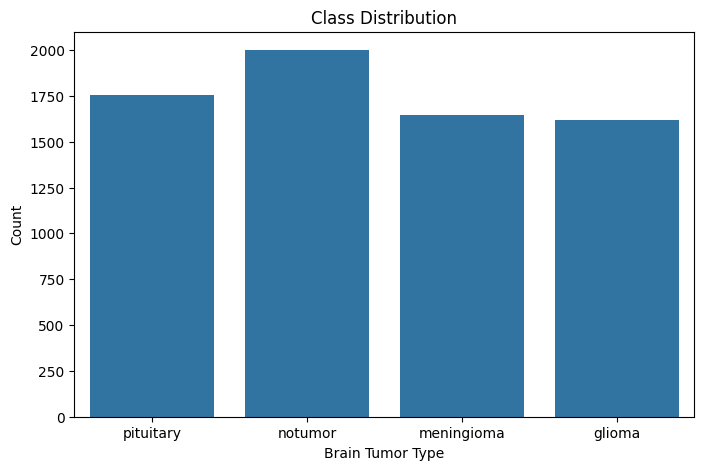

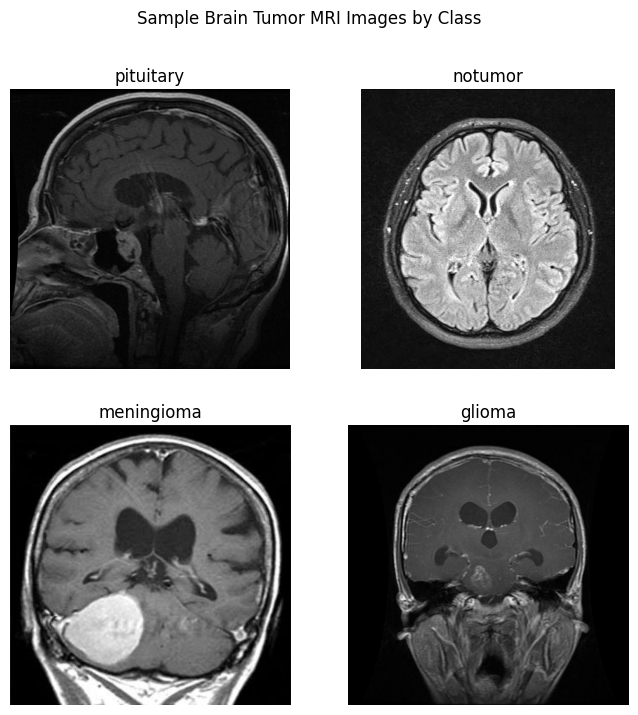

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

# This dataset is for multi-class image classification with four classes: glioma, meningioma, no tumor, and pituitary.
# The goal is to build a model that can classify an MRI image into one of these four categories.
data_dir_training = 'Training'
data_dir_testing = 'Testing'
classes = os.listdir(data_dir_training) # Assuming both training and testing have the same classes
file_paths = []
labels = []

# Process training data
for cls in classes:
    cls_path = os.path.join(data_dir_training, cls)
    for img_file in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_file))
        labels.append(cls)

# Process testing data
for cls in classes:
    cls_path = os.path.join(data_dir_testing, cls)
    for img_file in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_file))
        labels.append(cls)


df = pd.DataFrame({'file_path': file_paths, 'label': labels})

# Print the total number of images
print(f"Total number of images: {len(df)}")

# Print the number of images per class
print("\nNumber of images per class:")
print(df['label'].value_counts())

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

# Check class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.xlabel('Brain Tumor Type')
plt.ylabel('Count')
plt.show()

# Display sample images
fig, axes = plt.subplots(2, 2, figsize=(8,8))
for i, cls in enumerate(classes):
    img_path = df[df['label']==cls]['file_path'].sample().values[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i//2, i%2].imshow(img)
    axes[i//2, i%2].set_title(cls)
    axes[i//2, i%2].axis('off')
plt.suptitle('Sample Brain Tumor MRI Images by Class')
plt.show()